# LLM-разметка заказов 

In [28]:
import os
import sys
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
PROJECT_ROOT = Path().resolve()
DATA_PATH = PROJECT_ROOT / 'data' / 'llm_labeling.xlsx'
PROMPT_PATH = PROJECT_ROOT / 'docs' / 'llm_alert_resolution_labeling_prompt.md'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
FIGURES_DIR = PROJECT_ROOT / 'figures'
OUT_PARQUET = OUTPUT_DIR / 'llm_labels.parquet'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
SAMPLE_SIZE = 2000
MAX_WORKERS = 2
FORCE_RETRAIN = False
sys.path.insert(0, str(PROJECT_ROOT))
print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DATA_PATH:    {DATA_PATH.exists()} → {DATA_PATH}')
print(f'PROMPT_PATH:  {PROMPT_PATH.exists()}')
print(f'OUT_PARQUET:  {OUT_PARQUET}')
print(f'FORCE_RETRAIN: {FORCE_RETRAIN}')


PROJECT_ROOT: /Users/bolotnikovali/ИПС
DATA_PATH:    True → /Users/bolotnikovali/ИПС/data/llm_labeling.xlsx
PROMPT_PATH:  True
OUT_PARQUET:  /Users/bolotnikovali/ИПС/outputs/llm_labels.parquet
FORCE_RETRAIN: False


## 1. Проверка чекпойнта

In [29]:
_SKIP_LABELING = False
FORCE_RETRAIN = True
if OUT_PARQUET.exists() and (not FORCE_RETRAIN):
    try:
        df_labeled = pd.read_parquet(OUT_PARQUET)
        print(f'Найден готовый артефакт: {OUT_PARQUET}')
        print(f'  Размер: {df_labeled.shape[0]:,} строк × {df_labeled.shape[1]} колонок')
        ok_mask = df_labeled['llm_error'].isna() if 'llm_error' in df_labeled.columns else pd.Series(True, index=df_labeled.index)
        print(f'  Успешно размечено: {ok_mask.sum():,}')
        if 'llm_resolution_lvl_1' in df_labeled.columns:
            print('\n  Распределение llm_resolution_lvl_1:')
            print(df_labeled.loc[ok_mask, 'llm_resolution_lvl_1'].value_counts(dropna=False).to_string())
        print('\nДля принудительной перезаписи выставь FORCE_RETRAIN = True')
        _SKIP_LABELING = True
    except Exception as e:
        print(f'Не удалось прочитать чекпойнт ({e}) — запускаем разметку заново.')
if not _SKIP_LABELING:
    print('Чекпойнт не найден или FORCE_RETRAIN=True — будем размечать.')


Чекпойнт не найден или FORCE_RETRAIN=True — будем размечать.


## 2. Загрузка данных

In [30]:
if not _SKIP_LABELING:
    if not DATA_PATH.exists():
        raise FileNotFoundError(f'Не найден файл данных: {DATA_PATH}')
    try:
        import openpyxl
    except ImportError as e:
        raise ImportError('Установите openpyxl: pip install openpyxl') from e
    df_raw = pd.read_excel(DATA_PATH, engine='openpyxl')
    df_raw = df_raw.dropna(axis=1, how='all')
    if df_raw.shape[0] > 0:
        _type_pattern = '^(string|uint\\d*|int\\d*|double|float\\d*|bool)$'
        if df_raw.iloc[0].astype(str).str.match(_type_pattern).any():
            df_raw = df_raw.iloc[1:].reset_index(drop=True)
            print('Пропущена строка с именами типов YT.')
    print(f'Загружено: {df_raw.shape[0]:,} строк, {df_raw.shape[1]} колонок')
    if 'resolution_lvl_1' in df_raw.columns:
        _has_label = df_raw['resolution_lvl_1'].notna() & (df_raw['resolution_lvl_1'].astype(str).str.strip() != '') & (df_raw['resolution_lvl_1'].astype(str).str.lower() != 'nan')
        df_labeled_pool = df_raw.loc[_has_label].copy()
        print(f'С экспертной меткой: {len(df_labeled_pool):,} (отфильтровано без метки: {len(df_raw) - len(df_labeled_pool):,})')
    else:
        df_labeled_pool = df_raw.copy()
        print('Колонка resolution_lvl_1 не найдена — используем все строки.')


Пропущена строка с именами типов YT.
Загружено: 32,918 строк, 115 колонок
С экспертной меткой: 32,918 (отфильтровано без метки: 0)


## 3. Стратифицированная выборка

In [31]:
if not _SKIP_LABELING:
    MIN_PER_TYPE = 5
    if 'resolution_lvl_1' in df_labeled_pool.columns:
        _strat_parts = []
        for _, grp in df_labeled_pool.groupby('resolution_lvl_1', sort=False):
            _strat_parts.append(grp.sample(min(len(grp), MIN_PER_TYPE), random_state=42))
        strat = pd.concat(_strat_parts) if _strat_parts else df_labeled_pool.iloc[0:0]
        n_remaining = SAMPLE_SIZE - len(strat)
        if n_remaining > 0:
            pool_rest = df_labeled_pool.drop(index=strat.index, errors='ignore').copy()
            k = min(n_remaining, len(pool_rest))
            rest = pool_rest.sample(k, random_state=42) if k > 0 else pool_rest.iloc[0:0]
            df_sample = pd.concat([strat, rest]).sample(frac=1, random_state=42)
        else:
            df_sample = strat.sample(frac=1, random_state=42)
        print(f'К разметке: {len(df_sample):,} строк (стратифицированная выборка по resolution_lvl_1)')
        print(df_sample['resolution_lvl_1'].value_counts(dropna=False).to_string())
    else:
        df_sample = df_labeled_pool.head(SAMPLE_SIZE)
        print(f'К разметке: {len(df_sample):,} строк')


К разметке: 2,000 строк (стратифицированная выборка по resolution_lvl_1)
resolution_lvl_1
no_negativity           1326
identification_fraud     236
client_fraud             157
multiaccount              94
family_fraud              83
negative                  73
not_applicable            17
unknown                    8
social_engineering         6


## 4. Выбор рабочего эндпоинта

In [32]:
if not _SKIP_LABELING:
    if not os.environ.get('SOY_TOKEN'):
        try:
            from tokens import require_soy_token
            os.environ['SOY_TOKEN'] = require_soy_token()
        except Exception:
            raise RuntimeError('SOY_TOKEN не установлен.\nУстанови его: export SOY_TOKEN=<твой_токен>\nИли добавь в ~/.zshrc')
    from antifraud_components.labeling.eliza_client import ElizaClient
    from antifraud_components.labeling.llm_labeler import LLMLabeler
    eliza = ElizaClient.from_env(timeout=90)
    if not eliza.probe():
        raise RuntimeError('Ни один эндпоинт Eliza не ответил успешно.\nПроверь SOY_TOKEN и наличие VPN / доступа до api.eliza.yandex.net.')
    print(f'Эндпоинт: {eliza.base_url}')
    print(f'Модель:   {eliza.model_name}')


  qwen3-5-397b-a17b-fp8  vLLM models: ['/genesis/model/Qwen3.5-397B-A17B-FP8']
  ✗ qwen3-5-397b-a17b-fp8  chat/completions HTTP 429: {"error":"inflight limit exceeded: limit: 5, used: 5, requested: 6","request_id":"1777985981641846-10164449160429850992-fgj3gwlvspupq2he-BAL"}
  ✗ alice-ai-llm-235b-latest/generative  /v1/models: {"key":"DO_NOT_NEED_KEY","error":"non json response, answer in `raw_response`","raw_response":"Not implemented","attempt_count":1,"elapsed_time_ms":2,"last_request_duration_ms":2,"request_id":"1777985981664922-8228105314131812498-fgj3gwlvspupq2he-BAL"}
  glm-latest  vLLM models: ['/genesis/model']
✓ Working pair: model='/genesis/model'
  base_url=https://api.eliza.yandex.net/internal/glm-latest/v1
Эндпоинт: https://api.eliza.yandex.net/internal/glm-latest/v1
Модель:   /genesis/model


## 5. Разметка

In [33]:
if not _SKIP_LABELING:
    system_prompt = LLMLabeler._load_system_prompt(PROMPT_PATH)
    labeler = LLMLabeler(client=eliza, system_prompt=system_prompt, max_workers=MAX_WORKERS)
    print(f'Размечаем {len(df_sample):,} заказов с моделью {eliza.model_name}...')
    df_labeled = labeler.label_dataframe(df_sample)
    ok_mask = df_labeled['llm_error'].isna()
    print(f'\nУспешно: {ok_mask.sum():,}/{len(df_labeled):,}   Ошибок: {(~ok_mask).sum()}')
    print('\nРаспределение llm_resolution_lvl_1:')
    print(df_labeled.loc[ok_mask, 'llm_resolution_lvl_1'].value_counts(dropna=False).to_string())


Размечаем 2,000 заказов с моделью /genesis/model...
Labeling 2000 orders with model /genesis/model...


LLM labeling: 100%|██████████| 2000/2000 [55:19<00:00,  1.66s/it] 


Done. Errors: 0/2000

Успешно: 2,000/2,000   Ошибок: 0

Распределение llm_resolution_lvl_1:
llm_resolution_lvl_1
no_negativity         1925
multiaccount            30
negative                29
social_engineering       8
client_fraud             7
unknown                  1


## 6. Сохранение

In [34]:
if not _SKIP_LABELING:
    df_save = df_labeled.copy()
    for _col in df_save.select_dtypes(include='object').columns:
        df_save[_col] = df_save[_col].astype(str)
    df_save.to_parquet(OUT_PARQUET, index=False)
    print(f'Сохранено: {OUT_PARQUET}  ({len(df_save):,} строк)')
    llm_cols = [c for c in df_labeled.columns if c.startswith('llm_')]
    print(f'LLM-колонки ({len(llm_cols)}): {llm_cols}')
    ok_mask = df_labeled['llm_error'].isna()


Сохранено: /Users/bolotnikovali/ИПС/outputs/llm_labels.parquet  (2,000 строк)
LLM-колонки (10): ['llm_resolution_fraud', 'llm_resolution_negative', 'llm_resolution_no_fraud', 'llm_resolution_lvl_1', 'llm_resolution_lvl_2', 'llm_confidence', 'llm_reasoning', 'llm_escalation', 'llm_error', 'llm_raw']


## 7. Анализ результатов

Успешно размечено: 2,000 / 2,000



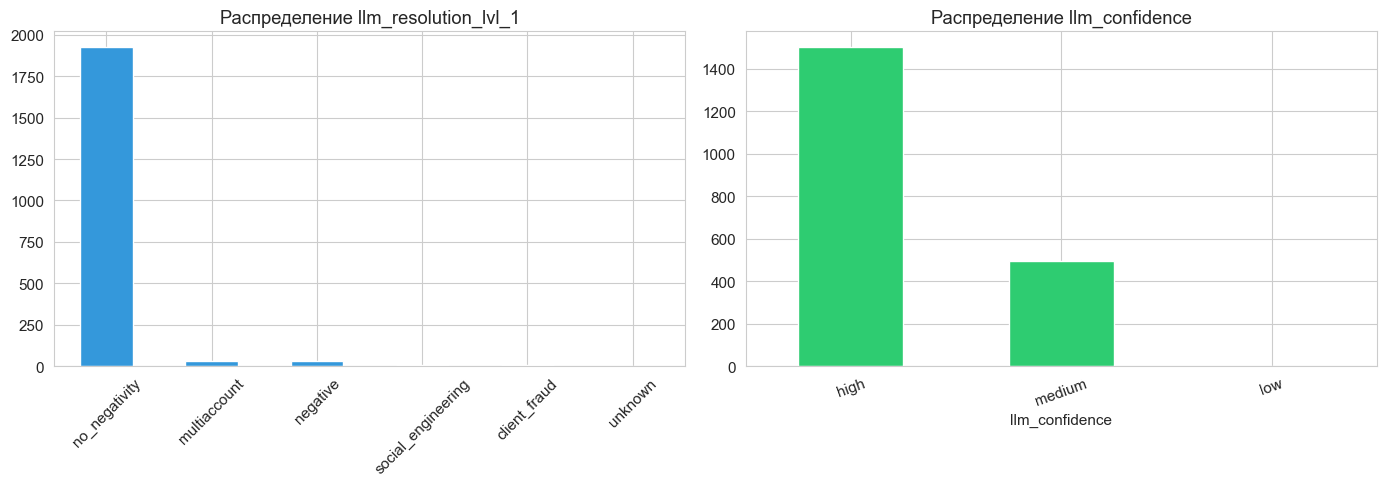

Сохранено: /Users/bolotnikovali/ИПС/figures/llm_labeling_distribution.png


In [36]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
if 'llm_error' in df_labeled.columns:
    _err_series = df_labeled['llm_error']
    ok_mask_analysis = _err_series.isna() | _err_series.astype(str).str.strip().str.lower().isin(['nan', 'none', ''])
else:
    ok_mask_analysis = pd.Series(True, index=df_labeled.index)
ok = df_labeled[ok_mask_analysis].copy()
print(f'Успешно размечено: {len(ok):,} / {len(df_labeled):,}')
if len(ok) == 0:
    print('Все строки отфильтрованы — показываем полный датасет.')
    ok = df_labeled.copy()
print()
lvl1_counts = ok['llm_resolution_lvl_1'].astype(str).value_counts(dropna=False)
conf_series = ok['llm_confidence'].astype(str) if 'llm_confidence' in ok.columns else pd.Series(['unknown'] * len(ok))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if len(lvl1_counts) > 0:
    lvl1_counts.plot.bar(ax=axes[0], color='#3498db')
else:
    axes[0].text(0.5, 0.5, 'Нет данных', ha='center', va='center', transform=axes[0].transAxes)
axes[0].set_title('Распределение llm_resolution_lvl_1')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)
conf_counts = conf_series.value_counts()
if len(conf_counts) > 0:
    conf_counts.plot.bar(ax=axes[1], color='#2ecc71')
else:
    axes[1].text(0.5, 0.5, 'Нет данных', ha='center', va='center', transform=axes[1].transAxes)
axes[1].set_title('Распределение llm_confidence')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
fig_path = FIGURES_DIR / 'llm_labeling_distribution.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Сохранено: {fig_path}')


Строк для сравнения: 2,000  (эскалаций LLM: 0)

Classification Report (fraud / negative / no_fraud)
              precision    recall  f1-score   support

        фрод       0.65      0.05      0.09       487
     негатив       0.53      0.09      0.15       178
без негатива       0.68      0.99      0.80      1335

    accuracy                           0.68      2000
   macro avg       0.62      0.37      0.35      2000
weighted avg       0.66      0.68      0.57      2000



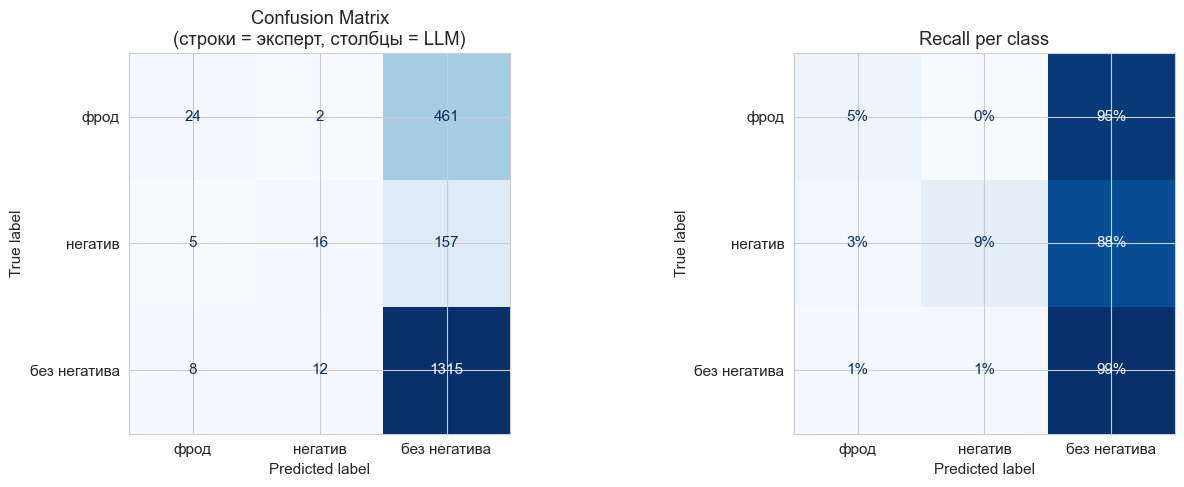

Сохранено: /Users/bolotnikovali/ИПС/figures/llm_3class_confusion.png


In [37]:
_expert_cols = ['resolution_fraud', 'resolution_negative', 'resolution_no_fraud']
_has_expert = all((c in ok.columns for c in _expert_cols))
if not _has_expert:
    print('Экспертные флаги не найдены — матрица согласованности пропущена.')
else:
    ok = ok.copy()
    for _col in _expert_cols + ['llm_resolution_fraud', 'llm_resolution_negative', 'llm_resolution_no_fraud']:
        if _col in ok.columns:
            ok[_col] = pd.to_numeric(ok[_col], errors='coerce').fillna(0).astype(int)

    def _row_3class(r_fraud, r_neg, r_nofr):
        if r_fraud == 1:
            return 'fraud'
        if r_neg == 1:
            return 'negative'
        if r_nofr == 1:
            return 'no_fraud'
        return None
    ok['expert_3class'] = ok.apply(lambda r: _row_3class(r.get('resolution_fraud', 0), r.get('resolution_negative', 0), r.get('resolution_no_fraud', 0)), axis=1)
    ok['llm_3class'] = ok.apply(lambda r: _row_3class(r.get('llm_resolution_fraud', 0), r.get('llm_resolution_negative', 0), r.get('llm_resolution_no_fraud', 0)), axis=1)
    cmp = ok.dropna(subset=['expert_3class', 'llm_3class'])
    if len(cmp) == 0:
        print('Нет строк для сравнения — пропускаем.')
    else:
        print(f"Строк для сравнения: {len(cmp):,}  (эскалаций LLM: {ok['llm_3class'].isna().sum()})")
        print()
        LABELS = ['fraud', 'negative', 'no_fraud']
        LABELS_RU = {'fraud': 'фрод', 'negative': 'негатив', 'no_fraud': 'без негатива'}
        print('=' * 60)
        print('Classification Report (fraud / negative / no_fraud)')
        print('=' * 60)
        print(classification_report(cmp['expert_3class'], cmp['llm_3class'], labels=LABELS, target_names=[LABELS_RU[l] for l in LABELS], zero_division=0))
        cm = confusion_matrix(cmp['expert_3class'], cmp['llm_3class'], labels=LABELS)
        labels_ru = [LABELS_RU[l] for l in LABELS]
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        ConfusionMatrixDisplay(cm, display_labels=labels_ru).plot(ax=axes[0], colorbar=False, cmap='Blues')
        axes[0].set_title('Confusion Matrix\n(строки = эксперт, столбцы = LLM)')
        cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
        ConfusionMatrixDisplay(np.round(cm_norm, 2), display_labels=labels_ru).plot(ax=axes[1], colorbar=False, cmap='Blues', values_format='.0%')
        axes[1].set_title('Recall per class')
        plt.tight_layout()
        fig_path = FIGURES_DIR / 'llm_3class_confusion.png'
        plt.savefig(fig_path, dpi=120, bbox_inches='tight')
        plt.show()
        print(f'Сохранено: {fig_path}')


## 8. Статус чекпойнта

In [38]:
if OUT_PARQUET.exists():
    _df_check = pd.read_parquet(OUT_PARQUET)
    ok_mask_check = _df_check['llm_error'].astype(str).eq('None') | _df_check['llm_error'].isna() if 'llm_error' in _df_check.columns else pd.Series(True, index=_df_check.index)
    print('Сохранённый чекпойнт:')
    print(f'  Файл:              {OUT_PARQUET}')
    print(f'  Размер:            {_df_check.shape[0]:,} × {_df_check.shape[1]}')
    print(f'  Успешно размечено: {ok_mask_check.sum():,}')
    if 'llm_resolution_lvl_1' in _df_check.columns:
        print(f'  Топ llm_resolution_lvl_1:')
        print('   ', _df_check.loc[ok_mask_check, 'llm_resolution_lvl_1'].value_counts(dropna=False).head(8).to_string().replace('\n', '\n    '))
    print()
    print('Пайплайн подтянет метки если FORCE_LLM_RETRAIN не установлен.')
else:
    print('Чекпойнт не найден — разметка не завершилась.')


Сохранённый чекпойнт:
  Файл:              /Users/bolotnikovali/ИПС/outputs/llm_labels.parquet
  Размер:            2,000 × 125
  Успешно размечено: 2,000
  Топ llm_resolution_lvl_1:
    llm_resolution_lvl_1
    no_negativity         1925
    multiaccount            30
    negative                29
    social_engineering       8
    client_fraud             7
    unknown                  1

Пайплайн подтянет метки если FORCE_LLM_RETRAIN не установлен.
